In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [31]:
## Cargamos los datos

data = pd.read_excel(r"PCA.xlsx")

data.head()

,Edad,Ingresos,Gasto_Anual,Numero_Compras,Ticket_Medio,Visitas_Web,Tiempo_Web,Emails_Abiertos,Uso_App,Antiguedad_Cliente
0,44.841783,55276.880054,6081.593832,27.240304,225.015212,37.085723,11.514799,12.462381,24.527306,6.944024
1,40.527642,51390.882541,6082.932935,26.292012,237.024357,38.109973,11.595134,12.208090,26.170144,4.693141
2,44.505433,44448.521101,4385.606200,20.977341,196.751253,52.839829,22.819393,17.170976,36.367117,5.941174
3,56.238392,56853.957942,6839.513374,28.950426,231.375538,52.733597,22.570162,17.438107,34.176630,7.289203
4,36.597951,54757.174389,6147.770896,27.140633,227.320458,44.937564,16.742471,14.746209,30.509755,3.630123


In [32]:
# Estandarizamos los datos
scaler = StandardScaler()
X = scaler.fit_transform(data)

In [33]:
# Generación del modelo PCA
pca = PCA()
components = pca.fit_transform(X)

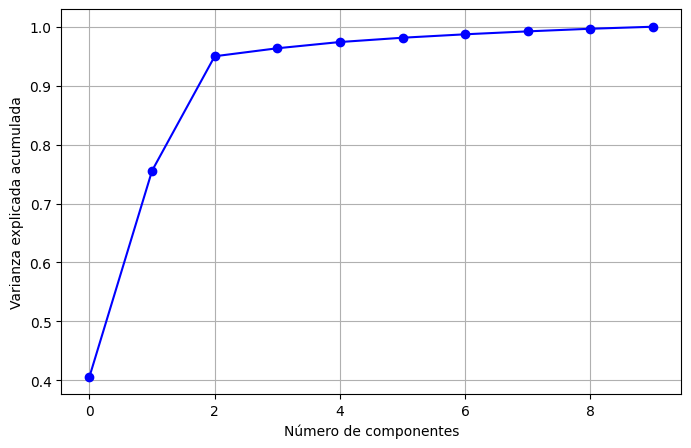

In [34]:
varianza = pca.explained_variance_ratio_

# Visualizacion de proporcion de varianza explicada por los factores

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(varianza), marker='o', color='blue')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

In [40]:
# Generacion de las componentes principales

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X)

X_pca.shape

(150, 3)

In [41]:
# Matriz de cargas 

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2', 'PC3'],
    index=data.columns
)
loadings=loadings.round(3)
print(loadings)

                      PC1    PC2    PC3
Edad               -0.039 -0.026  0.705
Ingresos            0.386 -0.319 -0.002
Gasto_Anual         0.393 -0.311  0.011
Numero_Compras      0.376 -0.321  0.019
Ticket_Medio        0.377 -0.333  0.008
Visitas_Web         0.308  0.394  0.012
Tiempo_Web          0.330  0.361  0.039
Emails_Abiertos     0.320  0.384  0.058
Uso_App             0.321  0.392  0.021
Antiguedad_Cliente -0.040 -0.028  0.705


In [ ]:
#PC1: Actividad transaccional
#PC2: Coportamiento de pago
#PC3: Comportamiento temporal